
📊 Sample Data:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

Training size: (404, 13)
Testing size: (102, 13)

Linear Regression Results:
➡ MSE  : 24.29
➡ RMSE : 4.93
➡ R2   : 0.67

Decision Tree Results:
➡ MSE  : 10.42
➡ RMSE : 3.23
➡ R2   : 0.86

Random Forest Results:
➡ MSE  : 7.90
➡ RMSE : 2.81
➡ R2   : 0.89

Final Conclusion:
👉 Random Forest gives best performance for this dataset.


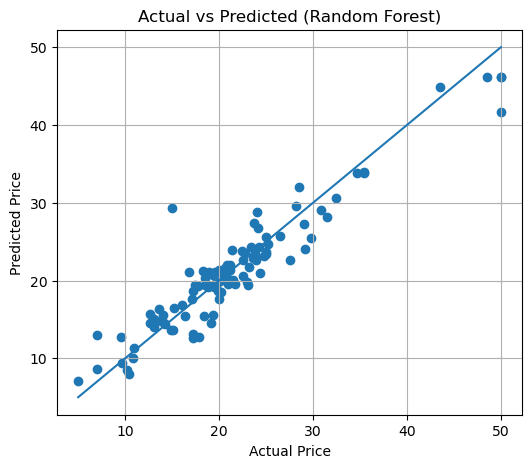


🔍 Top Important Features:
    Feature  Importance
5        RM    0.503845
12    LSTAT    0.309509
7       DIS    0.060549
0      CRIM    0.038062
10  PTRATIO    0.016313


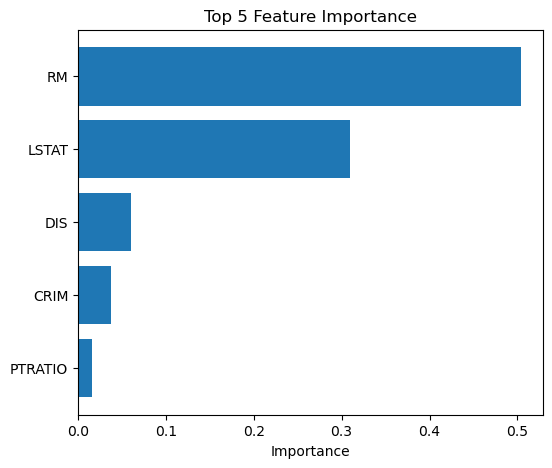

In [10]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# ================== LOAD DATASET ==================
df = pd.read_csv("housing.csv", sep=r'\s+', header=None)

df.columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
    "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"
]

print("\n📊 Sample Data:")
print(df.head(5))


# ================== FEATURES & TARGET ==================
X = df.drop("PRICE", axis=1)
y = df["PRICE"]


# ================== TRAIN-TEST SPLIT ==================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)


# ================== MODELS ==================
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)


# ================== TRAIN MODELS ==================
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)


# ================== PREDICTIONS ==================
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)


# ================== EVALUATION FUNCTION ==================
def evaluate(name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print(f"➡ MSE  : {mse:.2f}")
    print(f"➡ RMSE : {rmse:.2f}")
    print(f"➡ R2   : {r2:.2f}")


# ================== MODEL COMPARISON ==================
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)


print("\nFinal Conclusion:")
print("👉 Random Forest gives best performance for this dataset.")


# ================== GRAPH: ACTUAL VS PREDICTED ==================
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_rf)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.grid(True)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()


# ================== FEATURE IMPORTANCE ==================
importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

print("\n🔍 Top Important Features:")
print(feat_imp.head(5))


# ================== FEATURE IMPORTANCE GRAPH ==================
plt.figure(figsize=(6,5))
plt.barh(feat_imp["Feature"].head(5), feat_imp["Importance"].head(5))
plt.xlabel("Importance")
plt.title("Top 5 Feature Importance")
plt.gca().invert_yaxis()   # highest at top
plt.show()